# Day 5 — Matplotlib & Week 1 Mini-Notebook (Titanic Dataset)

This notebook brings together the full Week 1 pipeline on the Titanic `tested.csv` dataset: loading and cleaning the data with Pandas, computing a derived feature with NumPy, and visualizing the results with Matplotlib.

## 1. Load and Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (418, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


## 2. Missing Values
Check how many values are missing per column.

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Missing values in the `Age` column were replaced with the column's mean, rather than dropped, since the number of missing values is small relative to the size of the dataset. The `Cabin` column was dropped because most of its values are missing.

In [5]:
# Fill missing Age values with the column mean
df["Age"] = df["Age"].fillna(df["Age"].mean())
print(df["Age"].isnull().sum())

# Drop Cabin column
df = df.drop(columns=["Cabin"])



0


The single row with a missing `Fare` value was dropped, since it is only one row out of the whole dataset and cannot be reasonably estimated from a mean without more context.

In [6]:
df = df.dropna(subset=["Fare"])

## 3. NumPy Derived Feature
Use NumPy to compute a derived numeric feature and a summary statistic.

In [14]:
# mean of age 
mean_age = df["Age"].mean()
print (f"mean of age = {mean_age}")

mean of age = 30.20010256854757


## 4. Visualizations with Matplotlib
Numbers in a table hide patterns that a chart reveals instantly — trends, clusters, outliers, and relationships between variables. Every plot below is labeled with a title and axis labels, since an unlabeled chart is not a finding, it's a puzzle.

### Histogram — Age Distribution
A histogram shows the distribution (shape/spread) of a single variable.

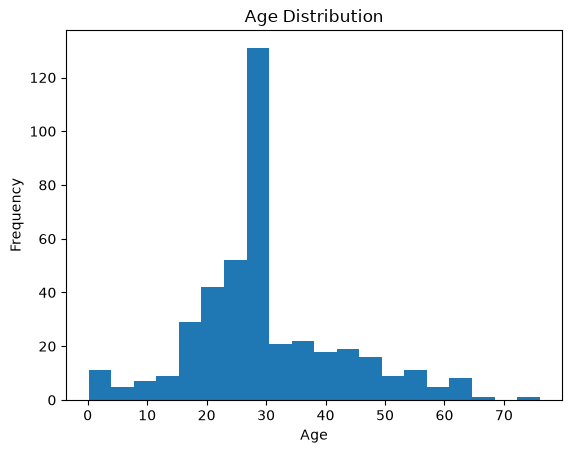

In [8]:
plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

Most passengers were young adults, with the distribution centered around the mean age used to fill missing values.

### Scatter Plot — Age vs Fare
A scatter plot shows the relationship between two numeric variables.

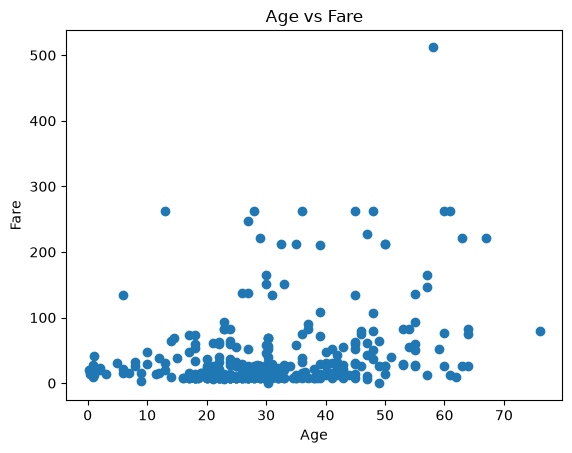

In [9]:
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

There is no strong linear relationship between age and fare, though a few older passengers paid notably higher fares.

### Bar Chart — Passengers by Class
A bar chart compares a value across categories.

In [10]:
class_counts = df["Pclass"].value_counts().sort_index()
print(class_counts)

Pclass
1    107
2     93
3    217
Name: count, dtype: int64


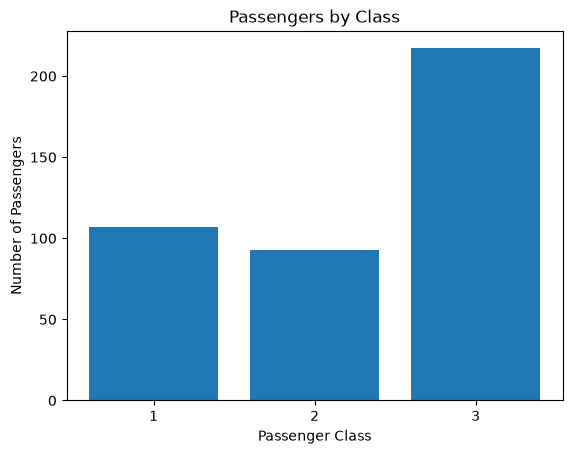

In [11]:
class_counts = df["Pclass"].value_counts().sort_index()

plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Passengers by Class")
plt.xticks([1, 2, 3])
plt.show()

Third class had the largest number of passengers, roughly double that of first or second class.

## 5. Subplots — Combined View
Subplots place multiple charts in one figure for side-by-side comparison, using `plt.subplots()` to create a grid of axes. This is essential for EDA, where several variables' distributions are often compared at once.

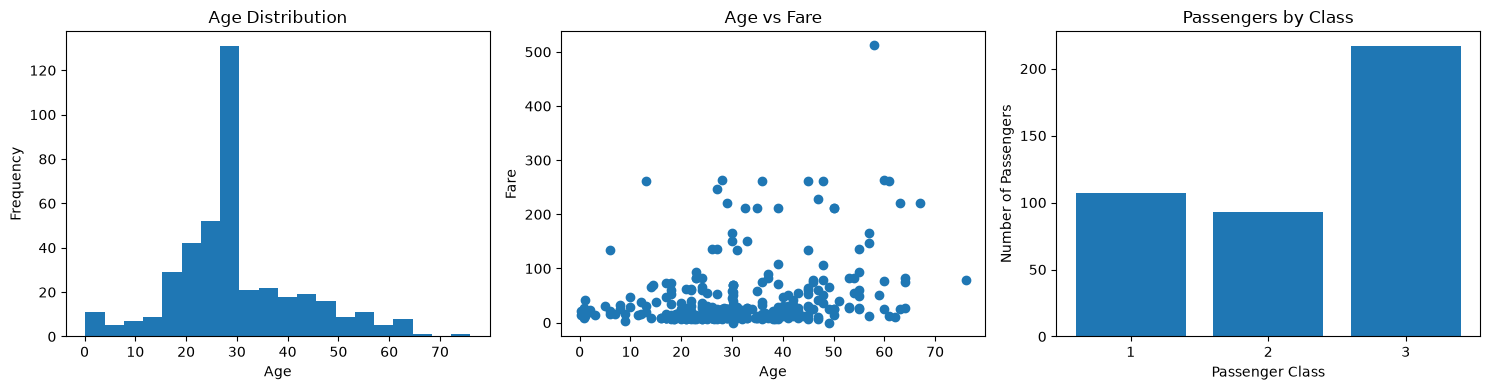

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df["Age"], bins=20)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Scatter plot
axes[1].scatter(df["Age"], df["Fare"])
axes[1].set_title("Age vs Fare")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Fare")

# Bar plot
axes[2].bar(class_counts.index, class_counts.values)
axes[2].set_title("Passengers by Class")
axes[2].set_xlabel("Passenger Class")
axes[2].set_ylabel("Number of Passengers")
axes[2].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

Viewing the histogram, scatter plot, and bar chart together makes it easy to compare age distribution, the age/fare relationship, and class sizes in a single glance.

## Summary
This mini-notebook practiced the full Week 1 pipeline: loading and cleaning the Titanic dataset with Pandas (handling missing values with a documented justification), computing a derived feature with NumPy, and producing labeled histogram, scatter, and bar plots with Matplotlib — including a combined subplots view for side-by-side comparison.